In [43]:
import pandas as pd
import numpy as np
import pyreadstat
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from pathlib import Path
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.decomposition import PCA



In [25]:
# utilities

def _define_plot_style(title='', xlabel='', ylabel='', figsize=(4, 6)):
    plt.style.use('_mpl-gallery')
    fig, ax = plt.subplots(figsize=figsize)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', alpha=0.5)
    return fig, ax


def save_and_display_plot(path):
    """
    Save the figure to the specified path.
    """
    filepath = Path(path)
    plt.savefig(filepath, format='pdf', bbox_inches='tight')
    plt.show()



In [3]:
df, meta = pyreadstat.read_sav('BD_MI_II_2024_25.sav')
# Uncomment the next line to see the entire dataframe
#with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.precision', 3):
#    display(df)

# uncomment the next line to see only the first 5 rows (Helpful just to check the type of data on each column)
# df.head()

len(df)



226

In [10]:
# Calculate scores for each subscale
stress_columns = ['DASS_1', 'DASS_6', 'DASS_8', 'DASS_11', 'DASS_12', 'DASS_14', 'DASS_18']
anxiety_columns = ['DASS_2', 'DASS_4', 'DASS_7', 'DASS_9', 'DASS_15', 'DASS_19', 'DASS_20']
depression_columns = ['DASS_3', 'DASS_5', 'DASS_10', 'DASS_13', 'DASS_16', 'DASS_17', 'DASS_21']

df['stress'] = df[stress_columns].sum(axis=1)
df['anxiety'] = df[anxiety_columns].sum(axis=1)
df['depression'] = df[depression_columns].sum(axis=1)



In [12]:
# standardize scores
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[["stress", "anxiety", "depression"]])

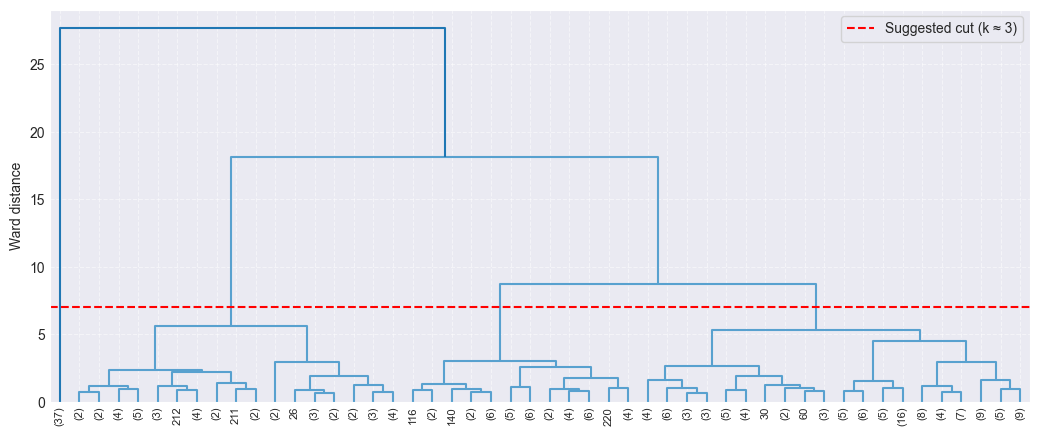

In [30]:
Z = linkage(X_scaled, method="ward")

_define_plot_style(title='', ylabel='Ward distance', figsize=(10, 4))
dendrogram(Z, truncate_mode="lastp", p=50, leaf_rotation=90)
plt.axhline(y=7.0, color='red', linestyle='--', label='Suggested cut (k ≈ 3)')
plt.legend()
save_and_display_plot('../figures/cluster/dendrogram.pdf')

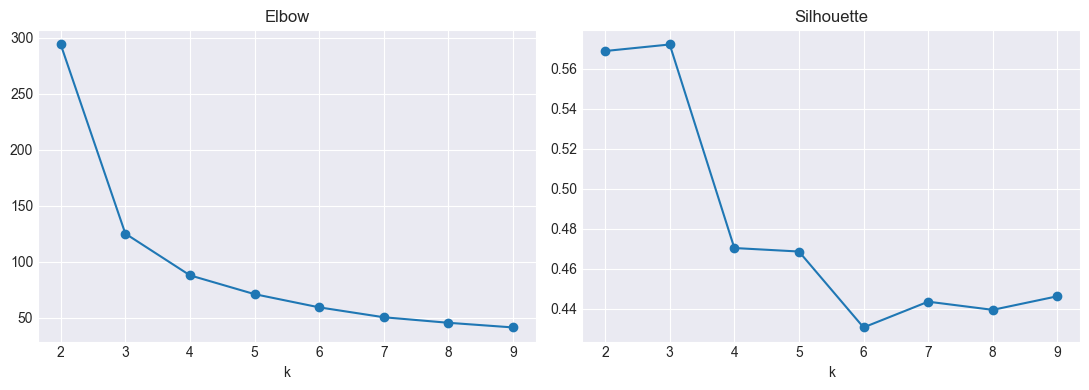

Best k by silhouette ≈ 3


In [34]:

sil = {}
inertia = {}
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil[k] = silhouette_score(X_scaled, labels)
    inertia[k] = km.inertia_

plt.figure(figsize=(11,4))

plt.subplot(1,2,1)
plt.plot(list(inertia.keys()), inertia.values(), marker="o")
plt.title("Elbow")
plt.xlabel("k")
plt.subplot(1,2,2)
plt.plot(list(sil.keys()), sil.values(), marker="o")
plt.title("Silhouette")
plt.xlabel("k")

plt.tight_layout()
save_and_display_plot('../figures/cluster/elbow_silhouette.pdf')

best_k = max(sil, key=sil.get)
print("Best k by silhouette ≈", best_k)

In [60]:
k = best_k
kmeans = KMeans(n_clusters=k, n_init=50, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

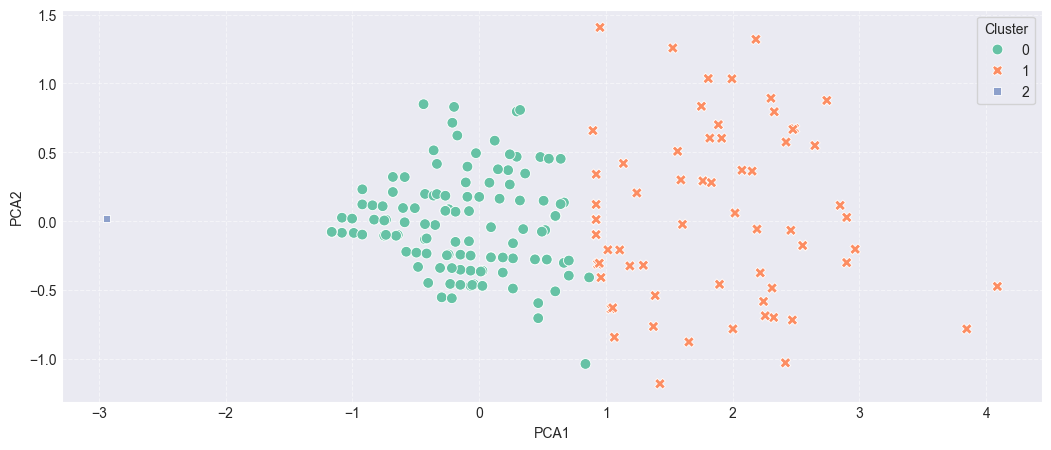

In [61]:
pca = PCA(n_components=2)
pca_pts = pca.fit_transform(X_scaled)
df["PCA1"], df["PCA2"] = pca_pts[:,0], pca_pts[:,1]

#plt.figure(figsize=(6,5))
_define_plot_style(title='', xlabel='PCA1', ylabel='PCA2', figsize=(10, 4))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Cluster", palette="Set2", s=60, style="Cluster")
plt.legend(title="Cluster")
save_and_display_plot('../figures/cluster/projected_clusters.pdf')

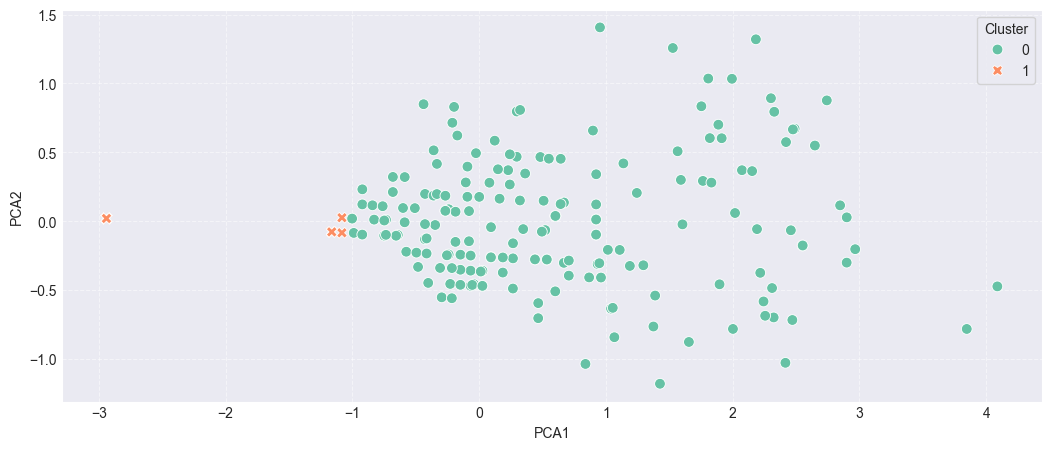

In [66]:
# rerun analysis with k = 2
k = 2
kmeans_2 = KMeans(n_clusters=k, n_init=50, random_state=42)
df["Cluster_2"] = kmeans_2.fit_predict(X_scaled)


pca_2 = PCA(n_components=2)
pca_pts_2 = pca_2.fit_transform(X_scaled)
df["PCA1_2"], df["PCA2_2"] = pca_pts_2[:,0], pca_pts_2[:,1]

#plt.figure(figsize=(6,5))
_define_plot_style(title='', xlabel='PCA1', ylabel='PCA2', figsize=(10, 4))
sns.scatterplot(data=df, x="PCA1_2", y="PCA2_2", hue="Cluster_2", palette="Set2", s=60, style="Cluster_2")
plt.legend(title="Cluster")
save_and_display_plot('../figures/cluster/projected_clusters_2.pdf')

df.drop('Cluster_2', axis=1, inplace=True)



depression       anxiety       stress       Count
              mean   std    mean   std   mean   std      
Cluster                                                  
0            10.97  2.68    9.89  2.40  12.57  3.12   122
1            19.49  4.49   16.82  4.04  20.69  3.21    67

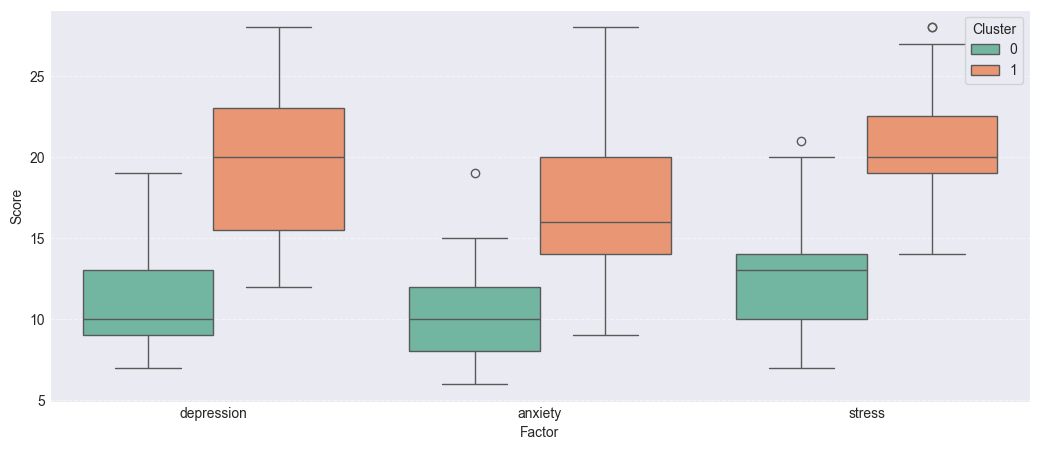

In [70]:
df_main = df[df["Cluster"].isin([0, 1])]


profile = (
    df_main.groupby("Cluster")[["depression", "anxiety", "stress"]]
    .agg(["mean","std"]).round(2)
)
profile["Count"] = df_main["Cluster"].value_counts()
display(profile)

# Optional visual:
df_melt = df_main.melt(id_vars="Cluster", value_vars=["depression","anxiety","stress"],
                  var_name="Factor", value_name="Score")
_define_plot_style(title='', xlabel='Factor', ylabel='Score', figsize=(10, 4))
sns.boxplot(x="Factor", y="Score", hue="Cluster", data=df_melt, palette="Set2")
save_and_display_plot('../figures/cluster/factor_boxplot.pdf')